# Projet : Analyse Spectrale – TD2
**Module :** TNS-GSTR1 – Traitement de Signal  
**École :** ENSA Tétouan  
**Année :** 2024-2025  
**réalisé par Ahlitta Yousra ,Fatiha Aharass ,Allou Daihi**  


Le but de ce projet est de réaliser une **analyse spectrale de différents signaux**.  
Nous allons combiner les **résultats théoriques**, les **simulations Python** (TD2) et les **résultats expérimentaux du laboratoire (NI ELVIS II+)** pour comprendre le comportement des signaux et l’effet du sampling, aliasing et filtrage.

<span style="color:red; font-weight:bold; font-size:18px;">Implémentation Python TD2 (Analyse Spectrale)</span>


## Question 1 : Signal x(t) = 5 cos(2π·1000 t)

**Énoncé :**  
Suppose that an analog signal is given as:  
Signal x(t) = 5 cos(2π·1000 t) 
and it is sampled at the rate of 8 kHz.

**Objectifs :**  
a. Sketch the spectrum for the original signal.  
b. Sketch the spectrum for the sampled signal from 0 to 20 kHz.


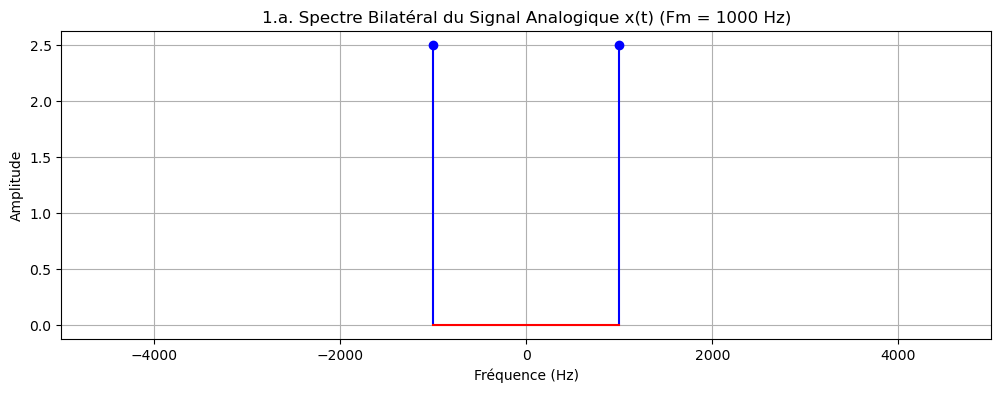

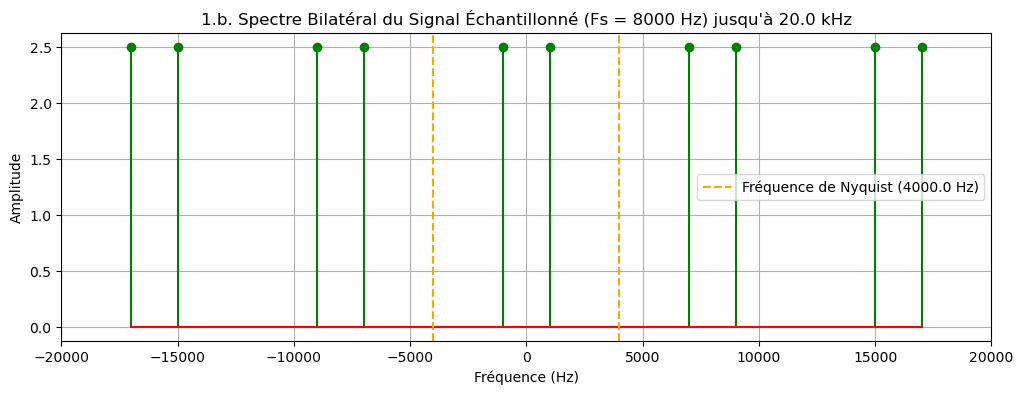

In [10]:
# --- Données de la question 1 ---
Fm1 = 1000  # Fréquence du signal analogique (Hz)
A1 = 5      # Amplitude
Fs1 = 8000  # Fréquence d'échantillonnage (Hz)
N1 = 1024   # Nombre de points pour le calcul FFT

# Fréquence de Nyquist
F_nyquist1 = Fs1 / 2

# --- Spectre du signal analogique (Partie 1.a) ---
# Le spectre est une paire de raies (Deltas de Dirac) à +/- Fm1, d'amplitude A1/2.
# Le tracé est un stem plot pour représenter les raies théoriques.

frequencies_analog1 = np.array([-Fm1, Fm1])
amplitudes_analog1 = np.array([A1/2, A1/2])

plt.figure(figsize=(12, 4))
plt.stem(frequencies_analog1, amplitudes_analog1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(f'1.a. Spectre Bilatéral du Signal Analogique x(t) (Fm = {Fm1} Hz)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(-5000, 5000)
plt.show()
# 
# --- Spectre du signal échantillonné (Partie 1.b) ---
# La transformée de Fourier du signal échantillonné est périodique avec une période Fs.
# Les raies apparaissent à F = +/- Fm1 + k*Fs (avec k = 0, +/-1, +/-2, ...)
# Nous allons simuler cela avec la FFT et tracer jusqu'à 20 kHz.

k_max = 2 # Périodes à afficher de chaque côté
frequencies_sampled1 = []
amplitudes_sampled1 = []

# Génération des fréquences spectrales
for k in range(-k_max, k_max + 1):
    frequencies_sampled1.extend([Fm1 + k * Fs1, -Fm1 + k * Fs1])
    amplitudes_sampled1.extend([A1/2, A1/2])

# Tri pour un meilleur affichage
frequencies_sampled1 = np.array(frequencies_sampled1)
amplitudes_sampled1 = np.array(amplitudes_sampled1)
sort_indices = np.argsort(frequencies_sampled1)
frequencies_sampled1 = frequencies_sampled1[sort_indices]
amplitudes_sampled1 = amplitudes_sampled1[sort_indices]

# Filtrer pour n'afficher que l'intervalle [-20 kHz, 20 kHz] (et 0 à 20 kHz pour l'unilatéral)
freq_min_plot = -20000
freq_max_plot = 20000

mask = (frequencies_sampled1 >= freq_min_plot) & (frequencies_sampled1 <= freq_max_plot)

plt.figure(figsize=(12, 4))
plt.stem(frequencies_sampled1[mask], amplitudes_sampled1[mask], linefmt='g-', markerfmt='go', basefmt='r-')
plt.axvline(F_nyquist1, color='orange', linestyle='--', label=f'Fréquence de Nyquist ({F_nyquist1} Hz)')
plt.axvline(-F_nyquist1, color='orange', linestyle='--')
plt.title(f'1.b. Spectre Bilatéral du Signal Échantillonné (Fs = {Fs1} Hz) jusqu\'à {freq_max_plot/1000} kHz')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(freq_min_plot, freq_max_plot)
plt.show()
# ```

**Remarque :**  
Le signal x(t) a une seule fréquence à 1000 Hz.  
Comme la fréquence d'échantillonnage Fe = 8 kHz > 2*f_max, il n'y a pas d'aliasing.  
Le spectre du signal échantillonné montre des pics aux multiples de Fe, ce qui correspond à la répétition périodique du spectre en fréquence.


## Question 2 : Signal x(t) = 5 cos(2π·2000 t) + 3 cos(2π·3000 t)

**Énoncé :**  
Assuming that an analog signal is given by:  

 Signal x(t) = 5 cos(2π·2000 t) + 3 cos(2π·3000 t)
 
and it is sampled at the rate of 8000 Hz.

**Objectifs :**  
a. Sketch the spectrum of the sampled signal up to 20 kHz.  
b. Sketch the recovered analog signal spectrum if an ideal LowPass Filter (LPF) with a cutoff frequency of 4 kHz is used to filter the sampled signal to recover the original signal.


 



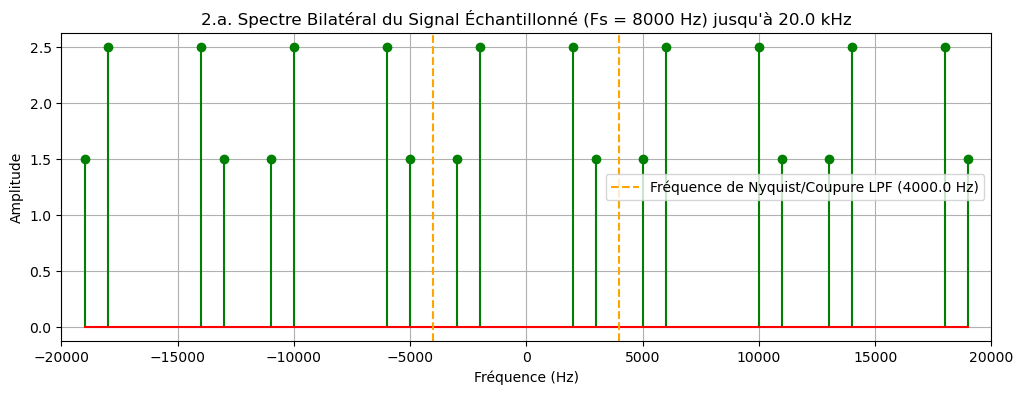

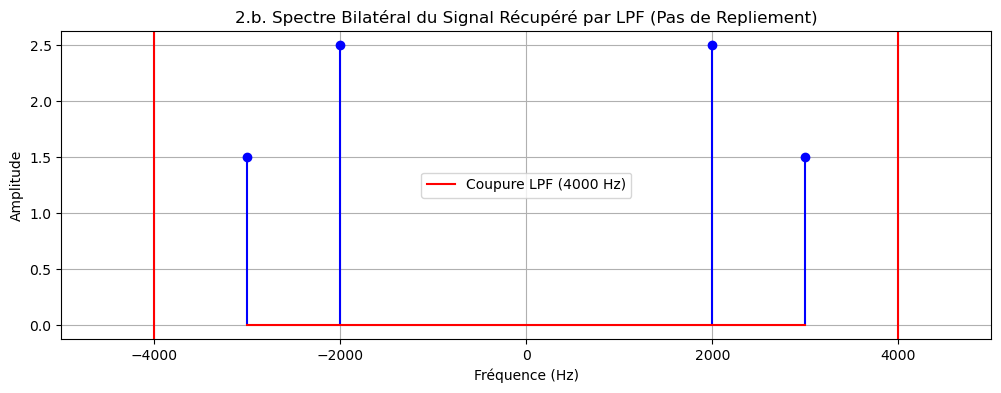

In [12]:

F1_2 = 2000   # Fréquence 1 (Hz)
A1_2 = 5      # Amplitude 1
F2_2 = 3000   # Fréquence 2 (Hz)
A2_2 = 3      # Amplitude 2
Fs2 = 8000    # Fréquence d'échantillonnage (Hz)

# Fréquence de Nyquist et de coupure du LPF
F_nyquist2 = Fs2 / 2
F_cutoff2 = 4000 # 4 kHz

# --- Spectre du signal échantillonné (Partie 2.a) ---
# Raies à +/- F1, +/- F2, et toutes les périodisations par +/- k*Fs

k_max = 2 # Périodes à afficher de chaque côté
frequencies_sampled2 = []
amplitudes_sampled2 = []

# Génération des fréquences spectrales pour F1 et F2
for k in range(-k_max, k_max + 1):
    # Composante F1
    frequencies_sampled2.extend([F1_2 + k * Fs2, -F1_2 + k * Fs2])
    amplitudes_sampled2.extend([A1_2/2, A1_2/2])
    # Composante F2
    frequencies_sampled2.extend([F2_2 + k * Fs2, -F2_2 + k * Fs2])
    amplitudes_sampled2.extend([A2_2/2, A2_2/2])

frequencies_sampled2 = np.array(frequencies_sampled2)
amplitudes_sampled2 = np.array(amplitudes_sampled2)

# Tri et masquage pour le tracé (jusqu'à 20 kHz)
freq_min_plot = -20000
freq_max_plot = 20000
mask = (frequencies_sampled2 >= freq_min_plot) & (frequencies_sampled2 <= freq_max_plot)

plt.figure(figsize=(12, 4))
plt.stem(frequencies_sampled2[mask], amplitudes_sampled2[mask], linefmt='g-', markerfmt='go', basefmt='r-')
plt.axvline(F_nyquist2, color='orange', linestyle='--', label=f'Fréquence de Nyquist/Coupure LPF ({F_nyquist2} Hz)')
plt.axvline(-F_nyquist2, color='orange', linestyle='--')
plt.title(f'2.a. Spectre Bilatéral du Signal Échantillonné (Fs = {Fs2} Hz) jusqu\'à {freq_max_plot/1000} kHz')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(freq_min_plot, freq_max_plot)
plt.show()
# 
# --- Spectre du signal récupéré (Partie 2.b) ---
# L'idéal LPF (F_cutoff = 4 kHz) ne laisse passer que la bande [-4 kHz, 4 kHz] (bande de Nyquist).
# Seules les raies originales de 2 kHz et 3 kHz (k=0) passent.

frequencies_recovered2 = []
amplitudes_recovered2 = []

# Seules les composantes dans la bande [-F_cutoff, F_cutoff] passent
for f, a in zip(frequencies_sampled2, amplitudes_sampled2):
    if abs(f) <= F_cutoff2 and f != 0:
        frequencies_recovered2.append(f)
        amplitudes_recovered2.append(a)

frequencies_recovered2 = np.array(frequencies_recovered2)
amplitudes_recovered2 = np.array(amplitudes_recovered2)
sort_indices = np.argsort(frequencies_recovered2)
frequencies_recovered2 = frequencies_recovered2[sort_indices]
amplitudes_recovered2 = amplitudes_recovered2[sort_indices]

plt.figure(figsize=(12, 4))
plt.stem(frequencies_recovered2, amplitudes_recovered2, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.axvline(F_cutoff2, color='red', linestyle='-', label=f'Coupure LPF ({F_cutoff2} Hz)')
plt.axvline(-F_cutoff2, color='red', linestyle='-')
plt.title('2.b. Spectre Bilatéral du Signal Récupéré par LPF (Pas de Repliement)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(-5000, 5000)
plt.show()
# ```

 
- Le signal contient deux fréquences : 2 kHz et 3 kHz.  
 - cette question illustre l'importance de choisir une fréquence d'échantillonnage suffisamment grande et l'utilisation de filtres pour **éviter les effets de repliement**.                      
 L'utilisation d'un filtre passe-bas idéal (cutoff = 4 kHz) permet de **récupérer la composante originale de 2 kHz** et d'atténuer celle de 3 kHz qui est repliée.

## Question 3 : Signal x(t) = 5 cos(2π·2000 t) + cos(2π·5000 t)

**Énoncé :**  
Given an analog signal:  
x(t) = 5 cos(2π·2000 t) + cos(2π·5000 t)
 
sampled at a rate of 8000 Hz.

**Objectifs :**  
a. Sketch the spectrum of the sampled signal up to 20 kHz.  
b. Sketch the recovered analog signal spectrum if an ideal lowpass filter with a cutoff frequency of 4 kHz is used to recover the original signal \([y(n)=x(n)]\).




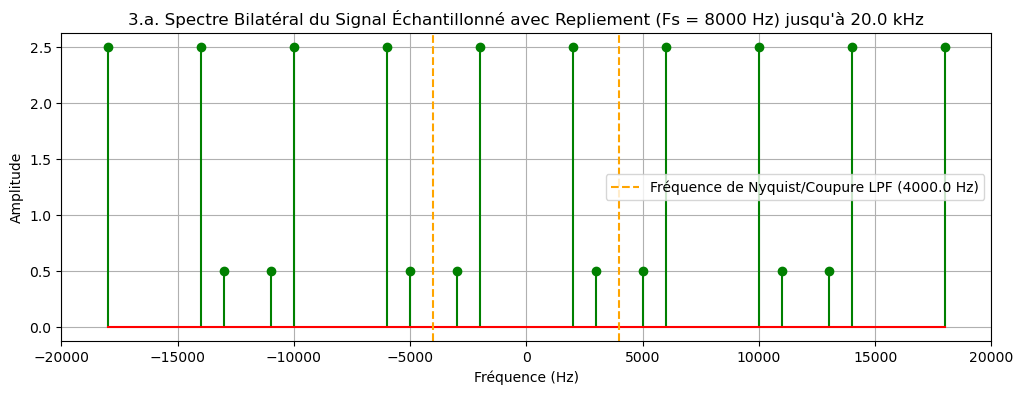

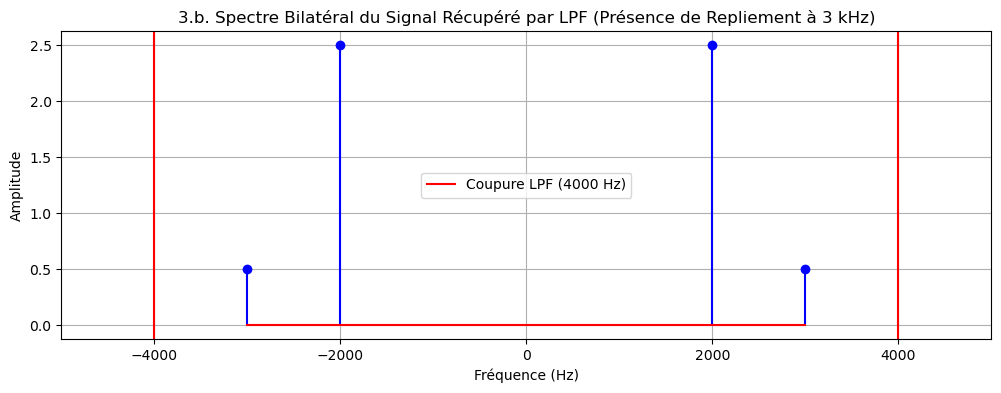

In [13]:

F1_3 = 2000   # Fréquence 1 (Hz)
A1_3 = 5      # Amplitude 1
F2_3 = 5000   # Fréquence 2 (Hz)  -> Va être repliée
A2_3 = 1      # Amplitude 2
Fs3 = 8000    # Fréquence d'échantillonnage (Hz)

# Fréquence de Nyquist et de coupure du LPF
F_nyquist3 = Fs3 / 2
F_cutoff3 = 4000 # 4 kHz

# --- Spectre du signal échantillonné (Partie 3.a) ---
# Raies à +/- F1, +/- F2, et toutes les périodisations par +/- k*Fs.
# La raie à +/- F2 va se superposer avec le repliement de F2
# Alias de F2 : F_alias = F2 - Fs = 5000 - 8000 = -3000 Hz
# et F_alias = -F2 + Fs = -5000 + 8000 = 3000 Hz
# Donc, une nouvelle raie apparaît à +/- 3000 Hz.

k_max = 2 # Périodes à afficher de chaque côté
frequencies_sampled3 = []
amplitudes_sampled3 = []

# Génération des fréquences spectrales pour F1 et F2
for k in range(-k_max, k_max + 1):
    # Composante F1: Amplitudes A1/2
    frequencies_sampled3.extend([F1_3 + k * Fs3, -F1_3 + k * Fs3])
    amplitudes_sampled3.extend([A1_3/2, A1_3/2])
    # Composante F2: Amplitudes A2/2
    frequencies_sampled3.extend([F2_3 + k * Fs3, -F2_3 + k * Fs3])
    amplitudes_sampled3.extend([A2_3/2, A2_3/2])

frequencies_sampled3 = np.array(frequencies_sampled3)
amplitudes_sampled3 = np.array(amplitudes_sampled3)

# Combinaison des amplitudes pour les fréquences repliées (aliased frequencies)
unique_freqs, indices = np.unique(frequencies_sampled3, return_inverse=True)
combined_amplitudes = np.zeros_like(unique_freqs, dtype=float)
for i, amp in enumerate(amplitudes_sampled3):
    combined_amplitudes[indices[i]] += amp

# Tri et masquage pour le tracé (jusqu'à 20 kHz)
freq_min_plot = -20000
freq_max_plot = 20000
mask = (unique_freqs >= freq_min_plot) & (unique_freqs <= freq_max_plot)

plt.figure(figsize=(12, 4))
plt.stem(unique_freqs[mask], combined_amplitudes[mask], linefmt='g-', markerfmt='go', basefmt='r-')
plt.axvline(F_nyquist3, color='orange', linestyle='--', label=f'Fréquence de Nyquist/Coupure LPF ({F_nyquist3} Hz)')
plt.axvline(-F_nyquist3, color='orange', linestyle='--')
plt.title(f'3.a. Spectre Bilatéral du Signal Échantillonné avec Repliement (Fs = {Fs3} Hz) jusqu\'à {freq_max_plot/1000} kHz')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(freq_min_plot, freq_max_plot)
plt.show()
# 
# --- Spectre du signal récupéré (Partie 3.b) ---
# L'idéal LPF (F_cutoff = 4 kHz) ne laisse passer que la bande [-4 kHz, 4 kHz] (bande de Nyquist).
# Les raies de 2 kHz et 3 kHz (l'alias) passent. L'information originale de 5 kHz est perdue.

frequencies_recovered3 = []
amplitudes_recovered3 = []

# Seules les composantes dans la bande [-F_cutoff, F_cutoff] passent
for f, a in zip(unique_freqs, combined_amplitudes):
    if abs(f) <= F_cutoff3 and f != 0:
        frequencies_recovered3.append(f)
        amplitudes_recovered3.append(a)

frequencies_recovered3 = np.array(frequencies_recovered3)
amplitudes_recovered3 = np.array(amplitudes_recovered3)
sort_indices = np.argsort(frequencies_recovered3)
frequencies_recovered3 = frequencies_recovered3[sort_indices]
amplitudes_recovered3 = amplitudes_recovered3[sort_indices]

plt.figure(figsize=(12, 4))
plt.stem(frequencies_recovered3, amplitudes_recovered3, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.axvline(F_cutoff3, color='red', linestyle='-', label=f'Coupure LPF ({F_cutoff3} Hz)')
plt.axvline(-F_cutoff3, color='red', linestyle='-')
plt.title('3.b. Spectre Bilatéral du Signal Récupéré par LPF (Présence de Repliement à 3 kHz)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(-5000, 5000)
plt.show()
# ``

 
- Le signal contient deux fréquences : 2 kHz et 5 kHz.  
- La fréquence d'échantillonnage Fe = 8 kHz < 2*f_max (Nyquist), donc la composante à 5 kHz subit un **aliasing** et apparaît repliée dans le spectre échantillonné.  
- Après application d'un filtre passe-bas idéal avec cutoff = 4 kHz, seule la composante à 2 kHz est conservée, ce qui permet de **récupérer partiellement le signal original**.  
- Cette question illustre l'importance de choisir une fréquence d'échantillonnage suffisamment grande et d'utiliser un filtre approprié pour **éviter ou limiter les effets de repliement (aliasing)**.


## Question 4 : Signal x(t) = 1 + cos(2π·2000 t) + 2 cos(2π·4000 t) + 3 cos(2π·6000 t)

**Énoncé :**  
Given an analog signal:  
x(t) = 1 + cos(2π·2000 t) + 2 cos(2π·4000 t) + 3 cos(2π·6000 t)
sampled at a rate of 8000 Hz.

**Objectifs :**  
a. Sketch the spectrum for the original signal.  
b. Sketch the unilateral spectrum of the sampled signal up to 40 kHz.  
c. Sketch the bilateral spectrum of the sampled signal up to 40 kHz.  
d. Conclude about b and c.  
e. Determine the aliasing frequencies.  
f. Sketch the recovered analog signal spectrum if an id


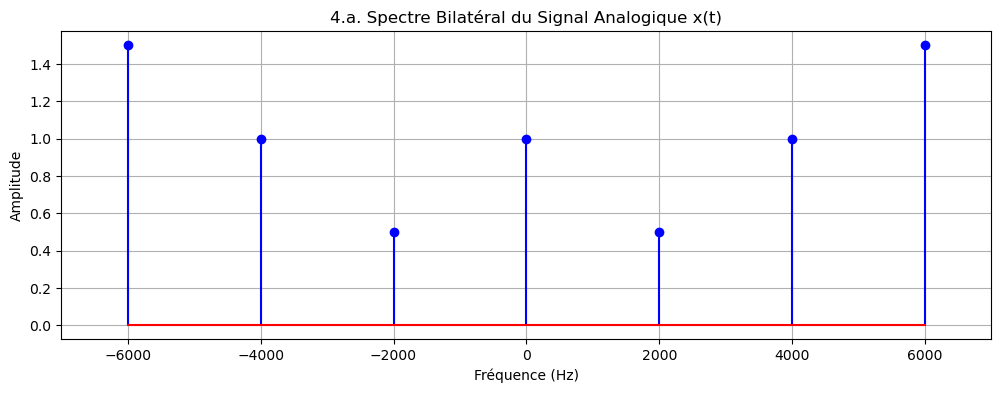

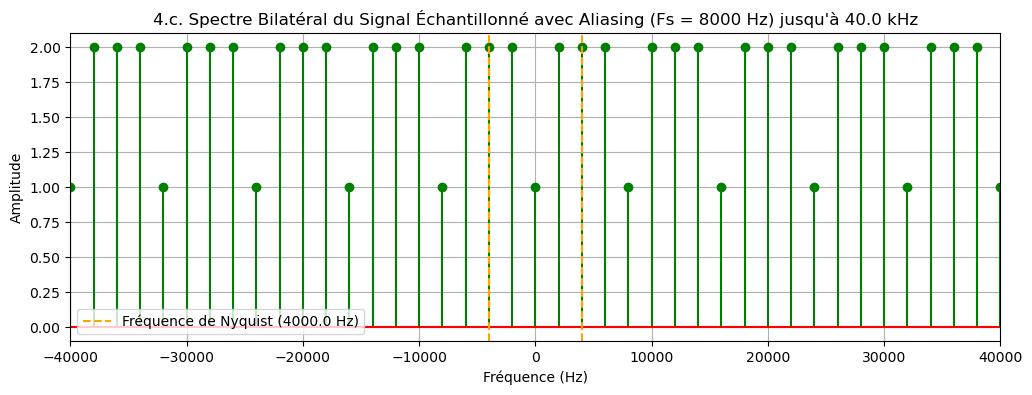

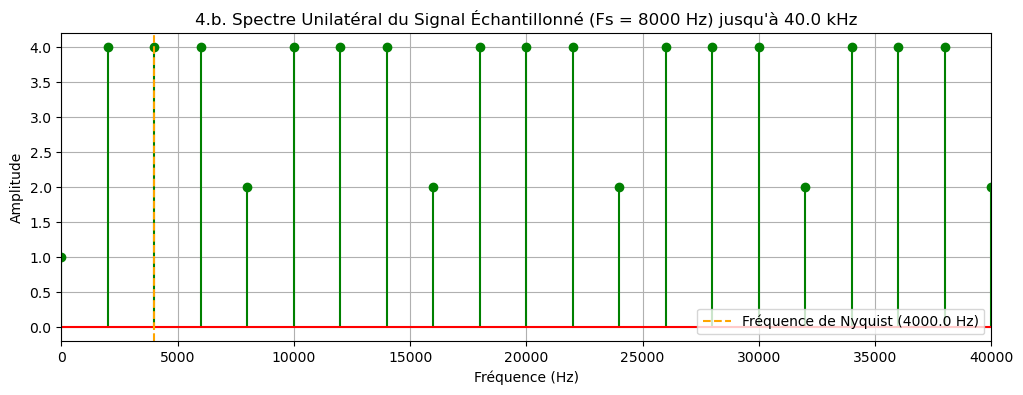

In [14]:
F_dc_4 = 0     # Fréquence DC (Hz)
A_dc_4 = 1     # Amplitude DC
F1_4 = 2000    # Fréquence 1 (Hz)
A1_4 = 1       # Amplitude 1
F2_4 = 4000    # Fréquence 2 (Hz) (Nyquist)
A2_4 = 2       # Amplitude 2
F3_4 = 6000    # Fréquence 3 (Hz) -> Repliée
A3_4 = 3       # Amplitude 3
Fs4 = 8000     # Fréquence d'échantillonnage (Hz)

F_nyquist4 = Fs4 / 2 # 4000 Hz

# --- Spectre du signal analogique (Partie 4.a) ---
frequencies_analog4 = np.array([0, -F1_4, F1_4, -F2_4, F2_4, -F3_4, F3_4])
amplitudes_analog4 = np.array([A_dc_4, A1_4/2, A1_4/2, A2_4/2, A2_4/2, A3_4/2, A3_4/2])

plt.figure(figsize=(12, 4))
plt.stem(frequencies_analog4, amplitudes_analog4, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('4.a. Spectre Bilatéral du Signal Analogique x(t)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(-7000, 7000)
plt.show()
# 

# --- Spectre du signal échantillonné (Parties 4.b et 4.c) ---
# La composante DC reste à 0 Hz. Amplitude = A_dc_4 = 1.
# La composante 2000 Hz: raie à 2000 Hz (A1/2) et à -2000 Hz (A1/2).
# La composante 4000 Hz (Nyquist): raie à +/- 4000 Hz (A2/2). **Attention, l'amplitude de la raie est A2/2 et elle n'est pas répétée à Fs +/- F2!**
# La composante 6000 Hz (Aliased): repliée à 2000 Hz (A3/2) et à -2000 Hz (A3/2).

k_max_unilateral = 5 # Pour aller jusqu'à 40 kHz, 40000/8000 = 5.
k_max_bilateral = 5 # Pour aller jusqu'à 40 kHz

# Création des fréquences et amplitudes (spectre bilatéral théorique)
frequencies_sampled4 = []
amplitudes_sampled4 = []

# Composante DC (k*Fs)
for k in range(-k_max_bilateral, k_max_bilateral + 1):
    frequencies_sampled4.append(0 + k * Fs4)
    amplitudes_sampled4.append(A_dc_4) # Le niveau DC est répété à chaque Fs

# Composante 2000 Hz (F1 + k*Fs)
for k in range(-k_max_bilateral, k_max_bilateral + 1):
    frequencies_sampled4.extend([F1_4 + k * Fs4, -F1_4 + k * Fs4])
    amplitudes_sampled4.extend([A1_4/2, A1_4/2])

# Composante 4000 Hz (Nyquist) - seulement à +/- 4000, +/- 12000, etc.
for k in range(-k_max_bilateral, k_max_bilateral + 1):
    # F = Fs/2 + k*Fs = (k+1/2)*Fs
    freq_nyquist_rep = F_nyquist4 + k * Fs4
    if abs(freq_nyquist_rep) <= Fs4 * k_max_bilateral:
        frequencies_sampled4.extend([freq_nyquist_rep, -freq_nyquist_rep])
        amplitudes_sampled4.extend([A2_4/2, A2_4/2])
    
# Composante 6000 Hz (F3 + k*Fs)
for k in range(-k_max_bilateral, k_max_bilateral + 1):
    frequencies_sampled4.extend([F3_4 + k * Fs4, -F3_4 + k * Fs4])
    amplitudes_sampled4.extend([A3_4/2, A3_4/2])

# Combinaison des amplitudes pour les fréquences superposées (superposition à 2 kHz)
frequencies_sampled4 = np.array(frequencies_sampled4)
amplitudes_sampled4 = np.array(amplitudes_sampled4)
unique_freqs4, indices4 = np.unique(frequencies_sampled4, return_inverse=True)
combined_amplitudes4 = np.zeros_like(unique_freqs4, dtype=float)
for i, amp in enumerate(amplitudes_sampled4):
    combined_amplitudes4[indices4[i]] += amp

# Tri pour un meilleur affichage
sort_indices4 = np.argsort(unique_freqs4)
unique_freqs4_sorted = unique_freqs4[sort_indices4]
combined_amplitudes4_sorted = combined_amplitudes4[sort_indices4]


# --- 4.c. Spectre Bilatéral jusqu'à 40 kHz ---
freq_max_plot = 40000
mask_bilateral = (unique_freqs4_sorted >= -freq_max_plot) & (unique_freqs4_sorted <= freq_max_plot)

plt.figure(figsize=(12, 4))
plt.stem(unique_freqs4_sorted[mask_bilateral], combined_amplitudes4_sorted[mask_bilateral], linefmt='g-', markerfmt='go', basefmt='r-')
plt.axvline(F_nyquist4, color='orange', linestyle='--', label=f'Fréquence de Nyquist ({F_nyquist4} Hz)')
plt.axvline(-F_nyquist4, color='orange', linestyle='--')
plt.title(f'4.c. Spectre Bilatéral du Signal Échantillonné avec Aliasing (Fs = {Fs4} Hz) jusqu\'à {freq_max_plot/1000} kHz')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(-freq_max_plot, freq_max_plot)
plt.show()
# 
# --- 4.b. Spectre Unilatéral jusqu'à 40 kHz ---
# Le spectre unilatéral n'affiche que les fréquences positives (incluant 0 Hz).
# Pour un signal réel, l'amplitude est doublée pour les fréquences F > 0, mais la composante DC (F=0) reste la même.

# Masque pour les fréquences positives
mask_unilateral = (unique_freqs4_sorted >= 0) & (unique_freqs4_sorted <= freq_max_plot)
freqs_unilateral = unique_freqs4_sorted[mask_unilateral]
amps_unilateral = combined_amplitudes4_sorted[mask_unilateral]

# Doubler l'amplitude pour F > 0 (conversion bilatéral -> unilatéral)
amps_unilateral_final = np.where(freqs_unilateral > 0, 2 * amps_unilateral, amps_unilateral)

plt.figure(figsize=(12, 4))
plt.stem(freqs_unilateral, amps_unilateral_final, linefmt='g-', markerfmt='go', basefmt='r-')
plt.axvline(F_nyquist4, color='orange', linestyle='--', label=f'Fréquence de Nyquist ({F_nyquist4} Hz)')
plt.title(f'4.b. Spectre Unilatéral du Signal Échantillonné (Fs = {Fs4} Hz) jusqu\'à {freq_max_plot/1000} kHz')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, freq_max_plot)
plt.show()
# ```


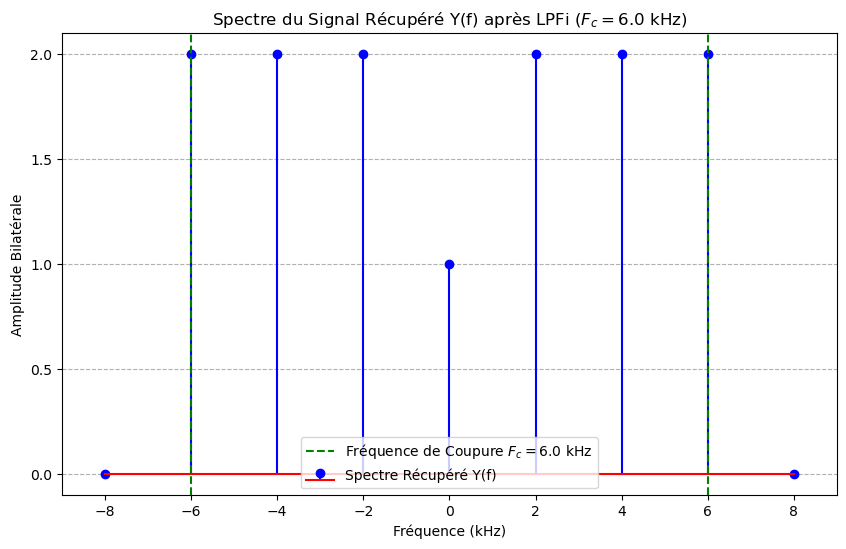

Fréquences (kHz) et Amplitudes (Bilatérales) du spectre récupéré Y(f):
f = -6 kHz, Amplitude = 2
f = -4 kHz, Amplitude = 2
f = -2 kHz, Amplitude = 2
f = 0 kHz, Amplitude = 1
f = 2 kHz, Amplitude = 2
f = 4 kHz, Amplitude = 2
f = 6 kHz, Amplitude = 2


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- Données du Problème ---
Fs = 8000  # Fréquence d'échantillonnage (Hz)
Fc = 6000  # Fréquence de coupure du filtre passe-bas (Hz)

# --- 1. Définir le Spectre Échantillonné Bilatéral X_s(f) ---

# Fréquences en kHz pour le tracé (suffisamment pour inclure Fs et Fc)
extended_freqs_kHz = np.array([-8, -6, -4, -2, 0, 2, 4, 6, 8])

# Amplitudes bilatérales de X_s(f) (Calculées selon le tableau ci-dessus)
# La séquence correspond à: [f=-8, f=-6, f=-4, f=-2, f=0, f=2, f=4, f=6, f=8]
X_s_amplitudes_extended = np.array([1, 2, 2, 2, 1, 2, 2, 2, 1])

# --- 2. Application du Filtre Passe-Bas Idéal (LPFi) ---

Y_amplitudes = np.copy(X_s_amplitudes_extended)

# Le filtre passe-bas idéal coupe toutes les composantes où |f| > Fc
for i, f_kHz in enumerate(extended_freqs_kHz):
    # Comparaison de |f| avec Fc (en kHz)
    if abs(f_kHz) > Fc / 1000.0:
        Y_amplitudes[i] = 0

# --- 3. Tracé du Spectre Récupéré Y(f) ---

plt.figure(figsize=(10, 6))

# Tracé des impulsions (stem plot)
plt.stem(extended_freqs_kHz, Y_amplitudes, linefmt='b-', markerfmt='bo', basefmt='r-', label='Spectre Récupéré Y(f)')

# Ajouter des lignes verticales pour la fréquence de coupure
Fc_kHz = Fc / 1000.0
plt.axvline(Fc_kHz, color='g', linestyle='--', label=f'Fréquence de Coupure $F_c={Fc_kHz}$ kHz')
plt.axvline(-Fc_kHz, color='g', linestyle='--')

# Mise en forme du graphique
plt.title(f"Spectre du Signal Récupéré Y(f) après LPFi ($F_c={Fc_kHz}$ kHz)")
plt.xlabel("Fréquence (kHz)")
plt.ylabel("Amplitude Bilatérale")
plt.grid(True, axis='y', linestyle='--')
plt.xticks(extended_freqs_kHz)
plt.yticks(np.arange(0, np.max(Y_amplitudes) + 0.5, 0.5))
plt.xlim(-9, 9)
plt.legend()
plt.show()

# --- Affichage des résultats numériques ---
print("Fréquences (kHz) et Amplitudes (Bilatérales) du spectre récupéré Y(f):")
for f, A in zip(extended_freqs_kHz, Y_amplitudes):
    if A != 0:
        print(f"f = {f} kHz, Amplitude = {A}")

<span style="color:blue; font-weight:bold; font-size:16px;">4.d Conclusion sur les spectres unilateral et bilateral</span>  
- Le spectre <span style="color:green;">unilateral (0 → 40 kHz)</span> montre uniquement les fréquences positives avec leurs amplitudes.  
- Le spectre <span style="color:orange;">bilateral (-Fe/2 → Fe/2)</span> montre les mêmes fréquences positives et leurs images négatives.  
- Les deux spectres contiennent la même information, mais le spectre bilateral permet de visualiser <span style="color:red;">la symétrie autour de 0 Hz</span>.

<br>

<span style="color:blue; font-weight:bold; font-size:16px;">4.e Fréquences d'aliasing</span>  
- La fréquence maximale du signal x(t) est <span style="color:purple;">6 kHz</span>, et la fréquence d'échantillonnage <span style="color:purple;">Fe = 8 kHz</span>.  
- Composantes > Fe/2 = 4 kHz vont se replier (<span style="color:red;">aliasing</span>) :  
  - 4 kHz : reste inchangée (<span style="color:green;">limite de Nyquist</span>)  
  - 6 kHz : apparaît à |Fe - 6 kHz| = 2 kHz (<span style="color:red;">aliasing</span>)  
- Donc l’aliasing concerne la composante 6 kHz qui est repliée à 2 kHz dans le spectre échantillonné.

<br>

<span style="color:blue; font-weight:bold; font-size:16px;">4.g Proposition de filtre pour récupérer le signal original</span>  
- Pour récupérer les composantes originales sans aliasing, il faut utiliser un <span style="color:green;">filtre passe-bas idéal</span> avec :  
  - Fréquence de coupure <span style="color:purple;">Fc ≥ 6 kHz</span> (pour inclure toutes les composantes originales)  
- Remarque : Pour éviter totalement l’aliasing, il faudrait <span style="color:red;">augmenter la fréquence d’échantillonnage Fe > 2*f_max = 12 kHz</span> avant le filtrage.
